# ORT: Special Relativity

**Chapters 1-10 | Formulas 1-22**

This notebook covers the part of the Ontological Relativity Theory (ORT) that
describes special relativity. The model rests on two principles: *everything
moves at speed $c$ through spacetime*, and *Invariance of Being*
($m \cdot v_t = m_0 c$).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent / 'shared'))
from ort_core import (C, ORT, NewtonModel, EinsteinModel)
from ort_plots import (velocity_circle, velocity_circle_interactive, gamma_curve,
    simultaneity_diagram, lorentz_transform_grid, zijn_vector_diagram, model_comparison_bar)
import math
import numpy as np
%matplotlib inline

---
## Chapter 1 -- Introduction

ORT rests on two intuitive principles:

> **Principle 1 — Velocity through time**
> Every object always moves at exactly the speed of light $c$ through
> four-dimensional spacetime. Time is a direction of motion just like
> the three spatial dimensions. An object at rest moves at 1 second per
> second through time — and that *is* the speed of light $c$. Accelerating
> through space means "borrowing" speed from the time direction.
>
> **Principle 2 — Invariance of Being**
> The product of an object's mass and its speed through time is constant:
> $m \cdot v_t = m_0 c$. Within ORT we call this the *Invariance of Being*:
> all observers see the same amount of Being. When an object moves faster
> through space and thus slower through time, its mass increases
> proportionally.

This notebook demonstrates that these two principles reproduce **all** effects of
special relativity: the Lorentz factor, E=mc$^2$, momentum, velocity addition,
simultaneity, and the full Lorentz transformation.

---
## Chapter 2 -- The Core Principle: The Velocity Sphere

### Equation (1) -- The velocity norm

$$v_{space}^2 + v_{time}^2 = c^2 \tag{1}$$

This is the equation of a 4D sphere with radius $c$ in velocity space
(shown here as a 2D cross-section in the $(v_{space}, v_{time})$ plane).
The angle $\theta$ measures the direction of the velocity vector relative to the time axis.

### Equations (2a) and (2b) -- Parameterization with $\theta$

$$v_{space} = c \sin\theta \tag{2a}$$
$$v_{time} = c \cos\theta \tag{2b}$$

- $\theta = 0$: object at rest, moving at $c$ through time
- $\theta = 90°$: photon, moving at $c$ through space, no progress through time

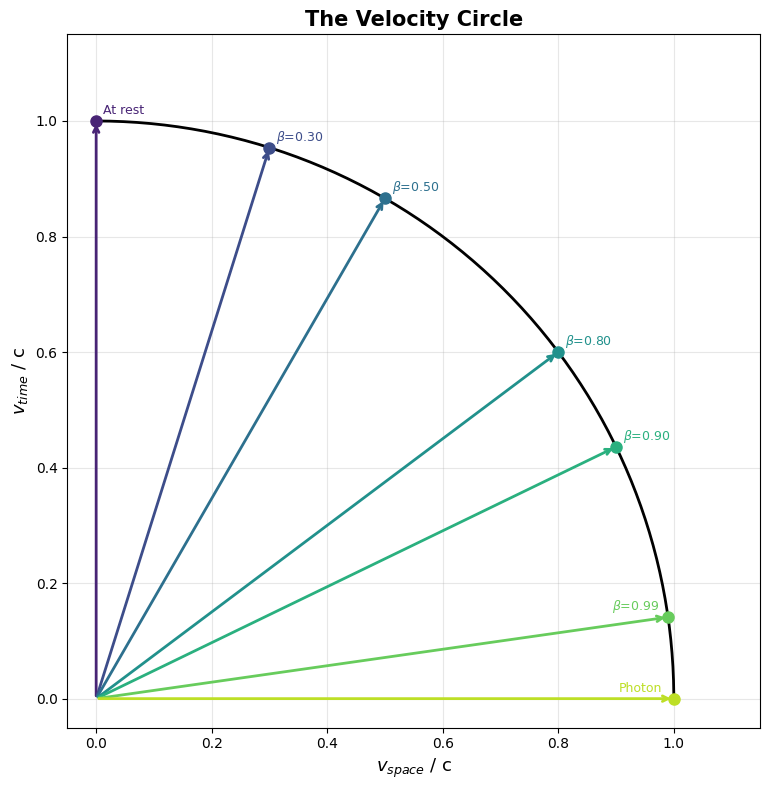

In [2]:
# The Velocity Sphere (2D cross-section)
velocity_circle(lang='en')
pass

In [3]:
# Interactive version -- move the slider to change beta
velocity_circle_interactive(lang='en')

interactive(children=(FloatSlider(value=0.5, description='β = v/c', max=0.999, readout_format='.3f', step=0.00…

---
## Chapter 3 -- Mathematical Formulation

All relativistic quantities follow directly from the angle $\theta$.

### Equation (5) -- Time dilation

$$\frac{d\tau}{dt} = \cos\theta \tag{5}$$

The proper time $\tau$ of a moving object ticks slower by a factor $\cos\theta$.

### Equation (5b) -- Length contraction

$$L = L_0 \cos\theta = L_0 \sqrt{1 - v^2/c^2} \tag{5b}$$

A rod in spacetime is a bundle of two worldlines (front and back),
separated perpendicularly by rest length $L_0$.

1. **At rest** ($\theta = 0$): both worldlines are vertical — pure time motion.
   A horizontal slice (simultaneity) intersects them at distance $L_0$.
2. **At velocity $v$**: the velocity vector rotates by angle $\theta = \arcsin(v/c)$
   on the velocity sphere. Both worldlines tilt by the same angle $\theta$.
3. **Measurement**: the observer measures length as the distance between the endpoints
   *at the same moment* — a horizontal slice through spacetime. Two parallel lines at
   angle $\theta$, with perpendicular separation $L_0$, intersect that horizontal line
   at distance $L_0 \cos\theta$.

### Equation (6) -- The Lorentz factor

$$\gamma = \frac{1}{\cos\theta} \tag{6}$$

The Lorentz factor from SRT is simply the secant of $\theta$.
In ORT, $\gamma$ is a derived notation, not a starting point.

### Equations (7) and (8) -- Energy

$$E = \frac{m_0 c^2}{\cos\theta} \tag{7}$$
$$E_k = \left(\frac{1}{\cos\theta} - 1\right) m_0 c^2 \tag{8}$$

> *Derived in chapter 4 via Invariance of Being and the work integral (equation 15).*

### Equation (9) -- Momentum

$$p = m_0 c \tan\theta \tag{9}$$

> *Derived in chapter 4: from $m_{rel} = m_0/\cos\theta$ (equation 14), which follows from Invariance of Being.*

### Equation (10) -- Relativistic velocity addition

$$v_{total} = \frac{v_1 + v_2}{1 + \frac{v_1 v_2}{c^2}} \tag{10}$$

This describes the addition of *spatial velocities* ($v = c\sin\theta$).

> *Follows from the Lorentz transformation (chapter 5, equations 22a-b).*

### Equation (11) -- Rapidity

$$\varphi = \text{artanh}(\sin\theta) \tag{11}$$

Rapidities are additive: $\varphi_{total} = \varphi_1 + \varphi_2$.

> *Rapidity is the standard term in relativistic physics (e.g. Rindler, Jackson).*

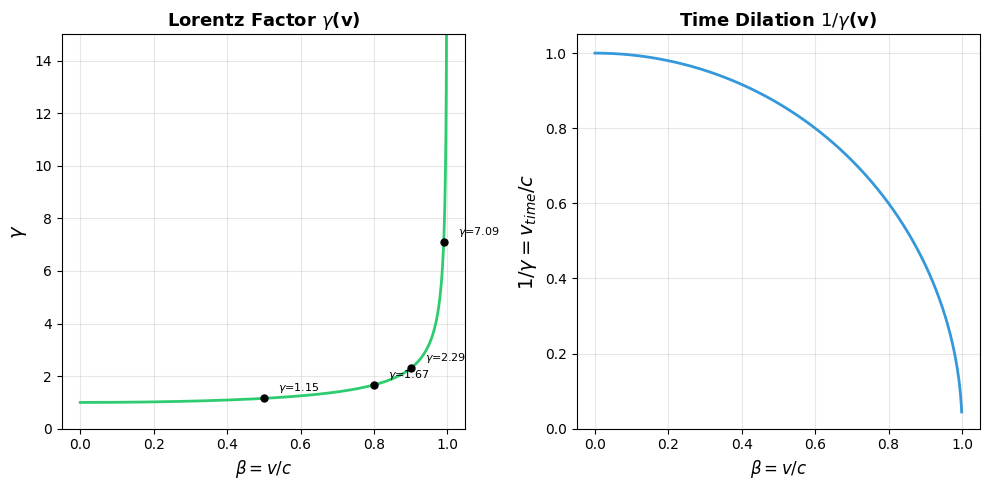

In [4]:
# Gamma curve: how gamma increases with velocity
gamma_curve(lang='en')
pass

In [5]:
# Compute gamma for various velocities
print(f"{'beta':>8}  {'theta (degrees)':>15}  {'gamma':>10}  {'v_time/c':>10}")
print("-" * 50)
for beta in [0.0, 0.1, 0.3, 0.5, 0.8, 0.9, 0.95, 0.99, 0.999]:
    stv = ORT.from_beta(beta)
    print(f"{beta:8.3f}  {math.degrees(stv.theta):15.2f}  {stv.gamma:10.4f}  {stv.v_time/C:10.6f}")

    beta  theta (degrees)       gamma    v_time/c
--------------------------------------------------
   0.000             0.00      1.0000    1.000000
   0.100             5.74      1.0050    0.994987
   0.300            17.46      1.0483    0.953939
   0.500            30.00      1.1547    0.866025
   0.800            53.13      1.6667    0.600000
   0.900            64.16      2.2942    0.435890
   0.950            71.81      3.2026    0.312250
   0.990            81.89      7.0888    0.141067
   0.999            87.44     22.3663    0.044710


In [ ]:
# Velocity addition: 0.8c + 0.8c does NOT give 1.6c
v1 = 0.8 * C
v2 = 0.8 * C

v_newton = NewtonModel.velocity_addition(v1, v2)
v_srt = EinsteinModel.velocity_addition(v1, v2)
v_ort = ORT.velocity_addition(v1, v2)

print(f"Velocity addition: {v1/C:.1f}c + {v2/C:.1f}c")
print(f"  Newton:  {v_newton/C:.4f}c  (WRONG: exceeds c!)")
print(f"  SRT:     {v_srt/C:.4f}c")
print(f"  ORT:     {v_ort/C:.4f}c  (= SRT)")
print()

# Rapidity verification -- SRT and ORT
phi1_srt = math.atanh(v1 / C)
phi2_srt = math.atanh(v2 / C)
phi_total_srt = phi1_srt + phi2_srt
v_from_phi_srt = C * math.tanh(phi_total_srt)

phi1_ort = ORT.rapidity(v1)
phi2_ort = ORT.rapidity(v2)
phi_total_ort = phi1_ort + phi2_ort
v_from_phi_ort = C * math.tanh(phi_total_ort)

print(f"Rapidity (SRT): phi1={phi1_srt:.4f} + phi2={phi2_srt:.4f} = {phi_total_srt:.4f}")
print(f"  v = c*tanh(phi_total) = {v_from_phi_srt/C:.4f}c")
print(f"Rapidity (ORT): phi1={phi1_ort:.4f} + phi2={phi2_ort:.4f} = {phi_total_ort:.4f}")
print(f"  v = c*tanh(phi_total) = {v_from_phi_ort/C:.4f}c")
print(f"  Difference SRT vs ORT: {abs(phi_total_srt - phi_total_ort):.2e}  (identical)")

---
## Chapter 4 -- Invariance of Being

The second principle of ORT: the *Being* of an object is defined as
the product of its relativistic mass and its velocity through time. This
product is **invariant** — it does not change with velocity.

The name *Ontological* Relativity Theory refers to this concept: ontology
is the philosophical study of *what exists*. ORT starts from Being —
the fundamental existence of an object ($m_0$) — as an invariant.

### Equation (12) -- Invariance of Being through time

$$S_{time} = m_{rel} \cdot v_{time} = m_0 c \tag{12}$$

The time-component of the Being-vector is invariant: all observers measure the
same $S_{time} = m_0 c$, regardless of the object's velocity.

### Equation (13) -- Energy corollary (derived)

$$E \cdot v_{time} = m_0 c^3 = S_{time} \cdot c^2 \tag{13}$$

This is not an independent postulate but a *consequence* of (12) and
$E = m_{rel} c^2$ (equation 7).

### Equation (14) -- Relativistic mass

From $S_{time} = m_0 c$ and $v_{time} = c\cos\theta$ follows:

$$m_{rel} = \frac{m_0 c}{v_{time}} = \frac{m_0}{\cos\theta} \tag{14}$$

This **derives the relativistic mass** from the model, instead of postulating it!
In SRT this is $\gamma m_0$; here it follows directly from the invariance of Being through time.

### Equation (15) -- E = mc² via the work integral

The factor $c^2$ is not postulated but **derived**. The key is the
standard definition of kinetic energy as work:

$$E_{kin} = \int F \, dx = \int v \, dp$$

We know $v$ and $p$ both as functions of $\theta$:

$$v = c\sin\theta \qquad \text{(equation 2a)}$$

$$p = \frac{m_0}{\cos\theta} \cdot c\sin\theta = m_0 c \tan\theta \qquad \text{(equations 14 + 2a)}$$

$$dp = \frac{m_0 c}{\cos^2\theta} \, d\theta$$

$$E_{kin} = \int_0^\theta c\sin\theta' \cdot \frac{m_0 c}{\cos^2\theta'} \, d\theta' = m_0 c^2 \int_0^\theta \frac{\sin\theta'}{\cos^2\theta'} \, d\theta'$$

This integral is standard ($\int \sin x / \cos^2 x \, dx = 1/\cos x$):

$$E_{kin} = m_0 c^2 \left(\frac{1}{\cos\theta} - 1\right) \tag{15}$$

> **The origin of $c^2$**: the product $v \cdot dp$ contains $c \cdot c$:
> one $c$ from velocity $v = c\sin\theta$, one $c$ from momentum $p = m_0 c \tan\theta$.
> The factor $c^2$ is a **computational consequence**, not a postulate.

The total energy is $E = E_{kin} + m_0 c^2 = m_0 c^2 / \cos\theta$ (equation 7).
At rest ($\theta = 0$) this reduces to $E_0 = m_0 c^2$.

### Equations (16)–(19) -- The Being-vector

The Being-vector $\vec{S}$ has two components:

$$S_{space} = p = m_0 c \tan\theta \quad \text{(varies)} \tag{16}$$
$$S_{time} = m_0 c \quad \text{(invariant — already defined in equation 12)} \tag{17}$$

**Being is time-momentum.** The structure is symmetric:

| | Through space | Through time |
|---|---|---|
| Velocity | $v = c\sin\theta$ | $d\tau/dt = \cos\theta$ |
| "Momentum" | $p = m_{rel} \cdot v$ | $m_{rel} \cdot d\tau/dt = m_0$ |

With dimensionless time-velocity $d\tau/dt = \cos\theta$, Invariance of Being reduces to:
$m_{rel} \cdot d\tau/dt = (m_0/\cos\theta) \cdot \cos\theta = m_0$. The conservation law simply says
that **rest mass is invariant**.

> **Why $S_{time} = m_0 c$ and not $m_0$?** The factor $c$ is not a unit choice.
> It follows directly from Principle 1: an object at rest moves at $v_{time} = c$
> through time. Invariance of Being then gives $m_0 \cdot c = m_0 c$.
> The table above uses the dimensionless time-velocity $d\tau/dt = \cos\theta$
> (which absorbs the $c$), while $S_{time}$ uses the full $v_{time} = c\cos\theta$.

The magnitude of the Being-vector:

$$|\vec{S}| = \frac{m_0 c}{\cos\theta} = \frac{E}{c} \quad \text{(derived, §4.4)} \tag{18}$$

Pythagoras on the Being-vector gives the **energy-momentum relation**:

$$E^2 = (pc)^2 + (m_0 c^2)^2 \tag{19}$$

### Connection with the four-momentum (SRT)

The Being-vector contains the same physics as the **four-momentum** $p^\mu$ from
special relativity theory (SRT), but the presentation differs fundamentally:

| Component | Four-momentum $p^\mu$ (SRT) | Being-vector $\vec{S}$ (ORT) |
|---|---|---|
| Space | $p$ | $S_{space} = p$ |
| Time | $p^0 = E/c$ | $S_{time} = m_0 c$ |
| Magnitude | $m_0 c$ (as norm) | $\lvert\vec{S}\rvert = E/c$ |

The four-momentum hides $m_0$ as a norm — you need to compute $\sqrt{p^\mu p_\mu}$
to recover the rest mass. The Being-vector makes the invariance of $m_0$
**directly visible as a component**: $S_{time} = m_0 c$ is right there.

### The derivation chain

$$\boxed{\text{Invariance of Being through time}} \xrightarrow{m \cdot v_t = m_0 c} m_{rel} = \frac{m_0}{\cos\theta} \xrightarrow{\int v \, dp} E = \frac{m_0 c^2}{\cos\theta} \xrightarrow{|\vec{S}| = E/c} E^2 = (pc)^2 + (m_0 c^2)^2$$

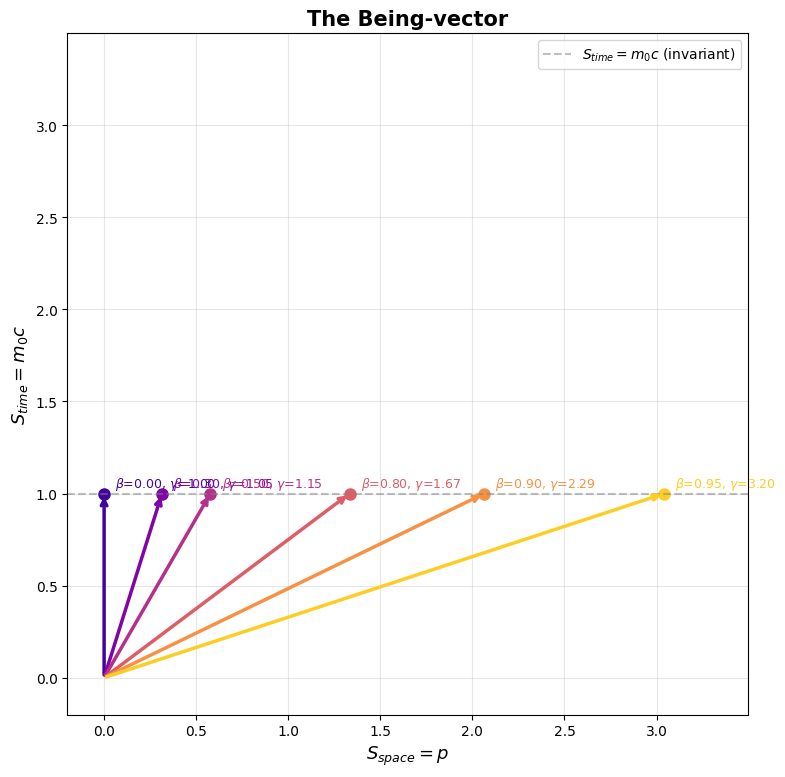

In [7]:
# Being-vector diagram
zijn_vector_diagram(lang='en')
pass

In [8]:
# Verification: Invariance of Being for various velocities
m0 = 1.0  # kg (unit mass)
print(f"Invariance of Being: S_m = m_rel * v_time = m0 * c = {m0 * C:.6e} kg*m/s")
print()
print(f"{'beta':>6}  {'m_rel (gamma*m0)':>16}  {'v_time (m/s)':>14}  {'S_m':>14}  {'= m0*c?':>10}")
print("-" * 70)
for beta in [0.0, 0.3, 0.5, 0.8, 0.9, 0.99]:
    stv = ORT.from_beta(beta)
    m_rel = stv.relativistic_mass(m0)
    v_t = stv.v_time
    s_m = m_rel * v_t
    match = abs(s_m - m0 * C) < 1e-6
    print(f"{beta:6.2f}  {m_rel:16.6f}  {v_t:14.2f}  {s_m:14.6e}  {'YES' if match else 'NO':>10}")

print()
print("The Being value is constant -- independent of velocity!")

Invariance of Being: S_m = m_rel * v_time = m0 * c = 2.997925e+08 kg*m/s

  beta  m_rel (gamma*m0)    v_time (m/s)             S_m     = m0*c?
----------------------------------------------------------------------
  0.00          1.000000    299792458.00    2.997925e+08         YES
  0.30          1.048285    285983777.98    2.997925e+08         YES
  0.50          1.154701    259627884.49    2.997925e+08         YES
  0.80          1.666667    179875474.80    2.997925e+08         YES
  0.90          2.294157    130676502.85    2.997925e+08         YES
  0.99          7.088812     42290930.54    2.997925e+08         YES

The Being value is constant -- independent of velocity!


In [9]:
# Verification: energy-momentum relation E^2 = (pc)^2 + (m0*c^2)^2
m0 = 1.0  # kg
print("Energy-momentum relation (equation 19):")
print(f"  m0*c^2 = {m0 * C**2:.6e} J\n")

for beta in [0.0, 0.5, 0.8, 0.99]:
    stv = ORT.from_beta(beta)
    E = stv.total_energy(m0)
    p = stv.momentum(m0)
    lhs = E**2
    rhs = (p * C)**2 + (m0 * C**2)**2
    print(f"  beta={beta:.2f}: E={E:.6e} J, p={p:.6e} kg*m/s")
    print(f"    E^2              = {lhs:.6e}")
    print(f"    (pc)^2+(m0c^2)^2 = {rhs:.6e}")
    print(f"    Match: {abs(lhs - rhs) / lhs < 1e-12}\n")

Energy-momentum relation (equation 19):
  m0*c^2 = 8.987552e+16 J

  beta=0.00: E=8.987552e+16 J, p=0.000000e+00 kg*m/s
    E^2              = 8.077609e+33
    (pc)^2+(m0c^2)^2 = 8.077609e+33
    Match: True

  beta=0.50: E=1.037793e+17 J, p=1.730853e+08 kg*m/s
    E^2              = 1.077014e+34
    (pc)^2+(m0c^2)^2 = 1.077014e+34
    Match: True

  beta=0.80: E=1.497925e+17 J, p=3.997233e+08 kg*m/s
    E^2              = 2.243780e+34
    (pc)^2+(m0c^2)^2 = 2.243780e+34
    Match: True

  beta=0.99: E=6.371107e+17 J, p=2.103921e+09 kg*m/s
    E^2              = 4.059100e+35
    (pc)^2+(m0c^2)^2 = 4.059100e+35
    Match: True



In [10]:
# Numerical verification: work integral E_kin = integral(v dp) = (gamma - 1) m0 c^2
# This is the NON-CIRCULAR derivation of E = mc^2 (§4.4)
m0 = 1.0  # kg

print("Work integral: E_kin = ∫ v dp = m₀c² (1/cos(θ) - 1)")
print(f"{'':>58} {'Numerical':>14} {'Analytical':>14} {'Difference':>14}")
print("-" * 100)

for beta in [0.1, 0.3, 0.5, 0.8, 0.9, 0.95, 0.99]:
    stv = ORT.from_beta(beta)

    # Numerical integral via the new method
    E_numerical = stv.kinetic_energy_integral(m0, n_steps=1_000_000)

    # Analytical result: (gamma - 1) m0 c^2
    E_analytical = stv.kinetic_energy(m0)

    rel_diff = abs(E_numerical - E_analytical) / E_analytical if E_analytical > 0 else 0

    print(f"  β = {beta:.2f}  θ = {math.degrees(stv.theta):6.2f}°  γ = {stv.gamma:8.4f}  "
          f"{E_numerical:14.6e} {E_analytical:14.6e} {rel_diff:14.2e}")

print()
print("The numerical work integral matches the analytical result.")
print("c² arises as c · c: one c from v = c·sin(θ), one c from p = m₀c·tan(θ).")

Work integral: E_kin = ∫ v dp = m₀c² (1/cos(θ) - 1)
                                                                Numerical     Analytical     Difference
----------------------------------------------------------------------------------------------------


  β = 0.10  θ =   5.74°  γ =   1.0050    4.527763e+14   4.527763e+14       3.06e-14


  β = 0.30  θ =  17.46°  γ =   1.0483    4.339625e+15   4.339625e+15       2.56e-14


  β = 0.50  θ =  30.00°  γ =   1.1547    1.390379e+16   1.390379e+16       6.47e-14


  β = 0.80  θ =  53.13°  γ =   1.6667    5.991701e+16   5.991701e+16       3.59e-13


  β = 0.90  θ =  64.16°  γ =   2.2942    1.163131e+17   1.163131e+17       8.31e-13


  β = 0.95  θ =  71.81°  γ =   3.2026    1.979565e+17   1.979565e+17       1.83e-12


  β = 0.99  θ =  81.89°  γ =   7.0888    5.472351e+17   5.472351e+17       9.84e-12

The numerical work integral matches the analytical result.
c² arises as c · c: one c from v = c·sin(θ), one c from p = m₀c·tan(θ).


---
## Chapter 5 -- Simultaneity and Co-locality

ORT contains an important duality principle:

> **Simultaneity** and **co-locality** are dual concepts,
> symmetric around the light line (45 degrees).

### Equation (20) -- Slope of simultaneity line

$$\alpha = \arctan(\sin\theta) \tag{20}$$

### Equation (21) -- Relativity of simultaneity

$$\Delta t' = \frac{\sin\theta}{c \cos\theta} \, \Delta x = \frac{\tan\theta}{c} \, \Delta x \tag{21}$$

Two events that are simultaneous in the rest frame ($\Delta t = 0$)
but at different positions, are **not** simultaneous in the moving frame.

In SRT this equation reads $\Delta t' = \gamma v \Delta x / c^2$, which is identical.

### Equations (22a) and (22b) -- The full Lorentz transformation

$$x' = \frac{x - c \sin\theta \cdot t}{\cos\theta} \tag{22a}$$
$$t' = \frac{t - \frac{\sin\theta}{c} \, x}{\cos\theta} \tag{22b}$$

In SRT this is written as $x' = \gamma(x - vt)$ and $t' = \gamma(t - vx/c^2)$.

ORT derives the **full** Lorentz transformation:
the spatial component (22a) follows from length contraction,
the temporal component (22b) follows from the simultaneity-colocality duality.

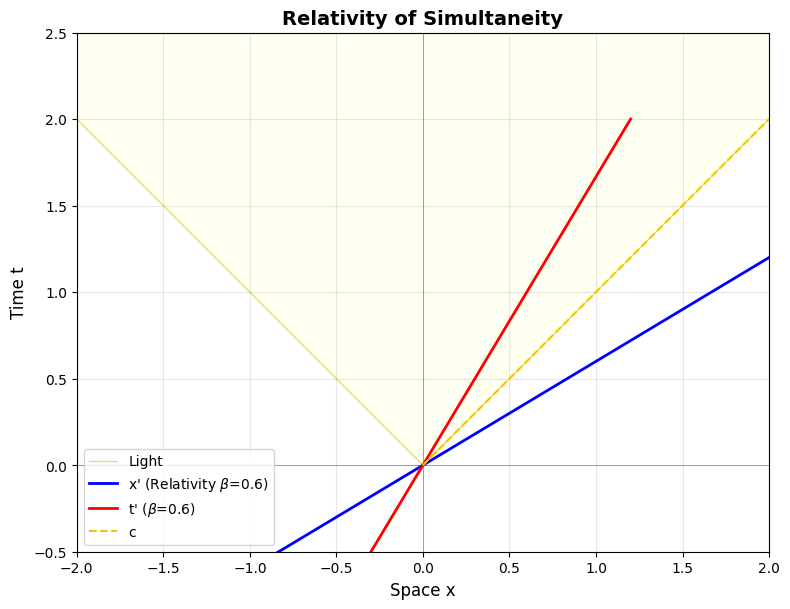

In [11]:
# Relativity of simultaneity
simultaneity_diagram(beta=0.6, lang='en')
pass

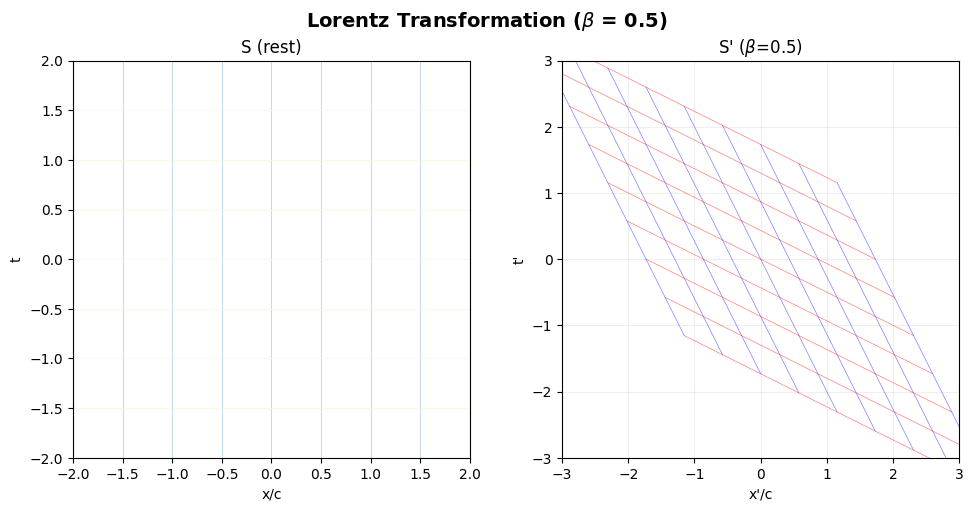

In [12]:
# Lorentz transformation: how the spacetime grid deforms
lorentz_transform_grid(beta=0.5, lang='en')
pass

In [13]:
# Numerical verification of the Lorentz transformation
beta = 0.6
stv = ORT.from_beta(beta)
v = stv.v_space
gamma = stv.gamma

print(f"Lorentz transformation for beta = {beta}, gamma = {gamma:.6f}")
print(f"v = {v:.2f} m/s\n")

# Test events (x in light-meters, t in seconds)
events = [
    (0, 0, "Origin"),
    (C, 0, "x=c, t=0 (simultaneous but not co-located)"),
    (0, 1, "x=0, t=1 (co-located but not simultaneous)"),
    (C, 1, "x=c, t=1"),
]

print(f"{'Event':<50} {'x':>12} {'t':>12} {'x_prime':>14} {'t_prime':>14}")
print("-" * 105)
for x, t, label in events:
    x_p, t_p = stv.lorentz_transform(x, t)
    # Verification with Einstein's formulas
    x_e = EinsteinModel.lorentz_x(x, t, v)
    t_e = EinsteinModel.lorentz_t(x, t, v)
    print(f"{label:<50} {x/C:12.4f}c {t:12.4f}s {x_p/C:14.4f}c {t_p:14.4f}s")
    assert abs(x_p - x_e) < 1e-6, "Mismatch!"
    assert abs(t_p - t_e) < 1e-6, "Mismatch!"

print("\nAll values match Einstein's Lorentz transformation exactly.")

Lorentz transformation for beta = 0.6, gamma = 1.250000
v = 179875474.80 m/s

Event                                                         x            t        x_prime        t_prime
---------------------------------------------------------------------------------------------------------
Origin                                                   0.0000c       0.0000s         0.0000c         0.0000s
x=c, t=0 (simultaneous but not co-located)               1.0000c       0.0000s         1.2500c        -0.7500s
x=0, t=1 (co-located but not simultaneous)               0.0000c       1.0000s        -0.7500c         1.2500s
x=c, t=1                                                 1.0000c       1.0000s         0.5000c         0.5000s

All values match Einstein's Lorentz transformation exactly.


---
## Chapter 6 -- Relativistic Effects

ORT describes all known relativistic effects in terms of the angle $\theta$:

| Effect | ORT ($\theta$-notation) | Equivalent ($\gamma$-notation) |
|--------|-------------------------|--------------------------------|
| Time dilation | $\tau = t\cos\theta$ | $= t/\gamma$ |
| Length contraction | $L = L_0\cos\theta$ | $= L_0/\gamma$ |
| Relativistic mass | $m = m_0/\cos\theta$ | $= \gamma m_0$ |
| Momentum | $p = m_0 c\tan\theta$ | $= \gamma m_0 v$ |

In [ ]:
# Relativistic effects at v = 0.8c -- Newton vs SRT vs ORT
beta = 0.8
v = beta * C
stv = ORT.from_beta(beta)
m0 = 1.0  # kg
L0 = 1.0  # m (rest length)
t_coord = 1.0  # s (coordinate time)
theta_deg = math.degrees(stv.theta)

print(f"=== Relativistic effects at beta = {beta} ===")
print(f"  theta = {theta_deg:.2f} degrees,  gamma = {stv.gamma:.6f}")
print()

# --- Time dilation ---
td_newton = NewtonModel.proper_time(t_coord, v)
td_srt = EinsteinModel.proper_time(t_coord, v)
td_ort = stv.proper_time(t_coord)

print(f"Time dilation (tau for t = {t_coord} s):")
print(f"  {'Newton':>8}: {td_newton:.6f} s  (no dilation)")
print(f"  {'SRT':>8}: {td_srt:.6f} s  (= t/gamma)")
print(f"  {'ORT':>8}: {td_ort:.6f} s  (= t*cos(theta))")
print()

# --- Length contraction ---
lc_newton = L0  # Newton: no contraction
lc_srt = EinsteinModel.length(L0, v)
lc_ort = stv.length_contraction(L0)

print(f"Length contraction (L0 = {L0} m):")
print(f"  {'Newton':>8}: {lc_newton:.6f} m  (no contraction)")
print(f"  {'SRT':>8}: {lc_srt:.6f} m  (= L0/gamma)")
print(f"  {'ORT':>8}: {lc_ort:.6f} m  (= L0*cos(theta))")
print()

# --- Momentum ---
p_newton = NewtonModel.momentum(m0, v)
p_srt = EinsteinModel.momentum(m0, v)
p_ort = stv.momentum(m0)

print(f"Momentum (m0 = {m0} kg):")
print(f"  {'Newton':>8}: {p_newton:.6e} kg*m/s  (= m0*v)")
print(f"  {'SRT':>8}: {p_srt:.6e} kg*m/s  (= gamma*m0*v)")
print(f"  {'ORT':>8}: {p_ort:.6e} kg*m/s  (= m0*c*tan(theta))")
print()

# --- Kinetic energy ---
ek_newton = NewtonModel.kinetic_energy(m0, v)
ek_srt = EinsteinModel.kinetic_energy(m0, v)
ek_ort = stv.kinetic_energy(m0)

print(f"Kinetic energy:")
print(f"  {'Newton':>8}: {ek_newton:.6e} J  (= 0.5*m0*v^2)")
print(f"  {'SRT':>8}: {ek_srt:.6e} J  (= (gamma-1)*m0*c^2)")
print(f"  {'ORT':>8}: {ek_ort:.6e} J  (= (1/cos(theta)-1)*m0*c^2)")
print()

# --- Verification SRT = ORT ---
print("Verification SRT = ORT:")
print(f"  Time dilation:      diff = {abs(td_srt - td_ort):.2e}")
print(f"  Length contraction:  diff = {abs(lc_srt - lc_ort):.2e}")
print(f"  Momentum:            diff = {abs(p_srt - p_ort):.2e}")
print(f"  Kinetic energy:      diff = {abs(ek_srt - ek_ort):.2e}")
print("  SRT and ORT give identical results!")

---
## Chapter 7 & 8 -- Model Comparison: Newton vs Einstein (SRT) vs ORT

A comparison of different aspects across these three models:

| Aspect | Newton | Einstein (SRT) | ORT |
|--------|--------|----------------|-----|
| Time dilation | None | $	au = t/gamma$ | $	au = tcos	heta$ |
| Length contraction | None |  = L_0/gamma$ |  = L_0 cos	heta$ |
| Velocity addition |  + v_2$ | Relativistic (rapidities additive) | Idem |
| Mass | Constant $ | $gamma m_0$ (relativistic) | /cos	heta$ from Being |
|  = mc^2$ | -- | Derived (momentum conservation + Lorentz) | Derived (Invariance of Being) |

### Derivation chain SRT vs ORT

| Step | SRT | ORT |
|------|-----|-----|
| Starting point | Relativity principle + $ = constant | Everything moves at $ + Invariance of Being |
| Gives | Lorentz transformations | Velocity sphere |
| Plus | Momentum conservation invariant under Lorentz |  cdot v_t = m_0 c$ |
| Gives |  = gamma m_0 v$ | {rel} = m_0/cos	heta$ |
| Via | Work integral | Work integral |
| Gives |  = gamma m_0 c^2$ |  = m_0 c^2/cos	heta$ |

Einstein (SRT) and ORT give **identical numerical results** — they describe the same
physics. The difference lies in interpretation: ORT makes the geometric structure
visible through the angle $	heta$, and derives /cos	heta$ and  = mc^2$ from
Invariance of Being. Newton diverges fundamentally at high velocities.

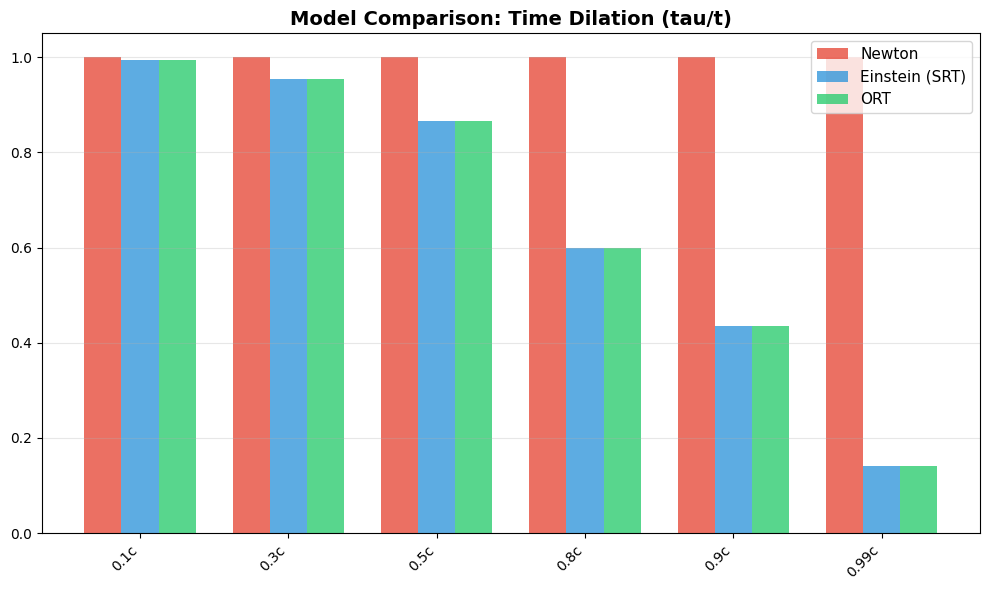

In [15]:
# Model comparison: time dilation at various velocities
betas_compare = [0.1, 0.3, 0.5, 0.8, 0.9, 0.99]
labels = [f'{b}c' for b in betas_compare]

newton_td = [1.0 for _ in betas_compare]  # Newton: no dilation
einstein_td = []
spacetime_td = []

for beta in betas_compare:
    v = beta * C
    stv = ORT.from_beta(beta)
    einstein_td.append(EinsteinModel.proper_time(1.0, v))
    spacetime_td.append(stv.proper_time(1.0))

values = {
    'labels': labels,
    'newton': newton_td,
    'einstein': einstein_td,
    'spacetime': spacetime_td
}
model_comparison_bar('Time Dilation (tau/t)', values, lang='en')
pass

In [16]:
# Detailed comparison table
m0 = 1.0  # kg
print(f"{'beta':>6} | {'Newton tau':>12} {'Einstein tau':>14} {'ORT tau':>14} | "
      f"{'Newton p':>14} {'Einstein p':>14} {'ORT p':>14}")
print("-" * 100)

for beta in [0.1, 0.3, 0.5, 0.8, 0.9, 0.95, 0.99]:
    v = beta * C
    stv = ORT.from_beta(beta)
    
    # Proper time for 1 second of coordinate time
    tau_n = NewtonModel.proper_time(1.0, v)
    tau_e = EinsteinModel.proper_time(1.0, v)
    tau_st = stv.proper_time(1.0)
    
    # Momentum
    p_n = NewtonModel.momentum(m0, v)
    p_e = EinsteinModel.momentum(m0, v)
    p_st = stv.momentum(m0)
    
    print(f"{beta:6.2f} | {tau_n:12.6f} {tau_e:14.6f} {tau_st:14.6f} | "
          f"{p_n:14.6e} {p_e:14.6e} {p_st:14.6e}")

print("\nEinstein (SRT) and ORT give identical results.")
print("Newton deviates increasingly at higher velocities.")

  beta |   Newton tau   Einstein tau        ORT tau |       Newton p     Einstein p          ORT p
----------------------------------------------------------------------------------------------------
  0.10 |     1.000000       0.994987       0.994987 |   2.997925e+07   3.013028e+07   3.013028e+07
  0.30 |     1.000000       0.953939       0.953939 |   8.993774e+07   9.428037e+07   9.428037e+07
  0.50 |     1.000000       0.866025       0.866025 |   1.498962e+08   1.730853e+08   1.730853e+08
  0.80 |     1.000000       0.600000       0.600000 |   2.398340e+08   3.997233e+08   3.997233e+08
  0.90 |     1.000000       0.435890       0.435890 |   2.698132e+08   6.189940e+08   6.189940e+08
  0.95 |     1.000000       0.312250       0.312250 |   2.848028e+08   9.120990e+08   9.120990e+08
  0.99 |     1.000000       0.141067       0.141067 |   2.967945e+08   2.103921e+09   2.103921e+09

Einstein (SRT) and ORT give identical results.
Newton deviates increasingly at higher velocities.


---
## Chapter 9 -- Thought Experiments

### 9.1 The Twin Paradox

A pair of twins: Alice stays on Earth, Bob travels at $v = 0.8c$ to a star
10 light-years away and back.

### 9.2 Muon Decay

Muons are created in the upper atmosphere (about 10 km altitude) and move at
$v \approx 0.998c$. Without relativity, they would decay in ~2.2 $\mu$s
and travel only ~660 m.

### 9.3 GPS SRT Correction

GPS satellites move at ~3.87 km/s. Special relativity causes a time delay.

In [17]:
# 9.1 Twin Paradox
print("=== Twin Paradox ===")
beta_bob = 0.8
distance_ly = 10  # light-years one way
stv_bob = ORT.from_beta(beta_bob)
theta_bob = math.degrees(stv_bob.theta)

t_alice_one_way = distance_ly / beta_bob
t_alice_total = 2 * t_alice_one_way

# ORT: proper time Bob = t * cos(theta)
t_bob_ort = t_alice_total * math.cos(stv_bob.theta)

# SRT: proper time Bob = t / gamma
t_bob_srt = t_alice_total / stv_bob.gamma

print(f"  Bob travels at {beta_bob}c to a star {distance_ly} light-years away")
print(f"  theta = {theta_bob:.2f} degrees")
print()
print(f"  Alice (Earth): {t_alice_total:.2f} years")
print(f"  Bob (ORT):  tau = t * cos(theta) = {t_alice_total:.2f} * cos({theta_bob:.2f}) = {t_bob_ort:.2f} years")
print(f"  Bob (SRT):  tau = t / gamma     = {t_alice_total:.2f} / {stv_bob.gamma:.4f}    = {t_bob_srt:.2f} years")
print(f"  Difference ORT vs SRT: {abs(t_bob_ort - t_bob_srt):.2e} years (identical)")
print()
print(f"  Bob is {t_alice_total - t_bob_ort:.2f} years younger upon return")

=== Twin Paradox ===
  Bob travels at 0.8c to a star 10 light-years away
  theta = 53.13 degrees

  Alice (Earth): 25.00 years
  Bob (ORT):  tau = t * cos(theta) = 25.00 * cos(53.13) = 15.00 years
  Bob (SRT):  tau = t / gamma     = 25.00 / 1.6667    = 15.00 years
  Difference ORT vs SRT: 0.00e+00 years (identical)

  Bob is 10.00 years younger upon return


In [ ]:
# 9.2 Muon Decay
print("=== Muon Decay ===")
beta_muon = 0.998
tau_muon = 2.2e-6  # rest lifetime in seconds
h_atmosphere = 10000  # height in meters

stv_muon = ORT.from_beta(beta_muon)
theta_muon = math.degrees(stv_muon.theta)

d_classical = beta_muon * C * tau_muon

# ORT: lifetime = tau / cos(theta)
t_ort = tau_muon / math.cos(stv_muon.theta)
d_ort = beta_muon * C * t_ort

# SRT: lifetime = tau * gamma
t_srt = tau_muon * stv_muon.gamma
d_srt = beta_muon * C * t_srt

print(f"  Muon speed: {beta_muon}c, theta = {theta_muon:.2f} degrees")
print(f"  Rest lifetime: {tau_muon*1e6:.1f} microseconds")
print()
print(f"  Without relativity:")
print(f"    Distance = {d_classical:.0f} m ({d_classical/1000:.2f} km) -- does NOT reach ground")
print()
print(f"  ORT: lifetime = tau / cos(theta) = {t_ort*1e6:.1f} us")
ort_reaches = "YES" if d_ort > h_atmosphere else "NO"
print(f"    Distance = {d_ort/1000:.1f} km -- reaches ground: {ort_reaches}")
print()
print(f"  SRT: lifetime = tau * gamma      = {t_srt*1e6:.1f} us")
srt_reaches = "YES" if d_srt > h_atmosphere else "NO"
print(f"    Distance = {d_srt/1000:.1f} km -- reaches ground: {srt_reaches}")
print()
print(f"  Difference ORT vs SRT: {abs(d_ort - d_srt):.2e} m (identical)")

In [19]:
# 9.3 GPS SRT correction
print("=== GPS Special Relativity Correction ===")
v_gps = 3870  # m/s (GPS satellite orbital speed)
stv_gps = ORT.from_v(v_gps)
theta_gps = stv_gps.theta
seconds_per_day = 86400

# ORT: proper time = t * cos(theta)
tau_ort = seconds_per_day * math.cos(theta_gps)
delta_ort = seconds_per_day - tau_ort

# SRT: proper time = t / gamma
tau_srt = seconds_per_day / stv_gps.gamma
delta_srt = seconds_per_day - tau_srt

print(f"  Orbital speed: {v_gps} m/s")
print(f"  theta = {math.degrees(theta_gps):.6f} degrees")
print()
print(f"  ORT: tau = t * cos(theta)")
print(f"    Time delay per day: {delta_ort*1e9:.2f} nanoseconds")
print()
print(f"  SRT: tau = t / gamma")
print(f"    Time delay per day: {delta_srt*1e9:.2f} nanoseconds")
print()
print(f"  Difference ORT vs SRT: {abs(delta_ort - delta_srt)*1e9:.4f} ns (identical)")
print()
print(f"  Satellite clock runs SLOWER due to motion (SRT).")
print(f"  (Note: GRT causes a SPEEDUP due to less gravity, which is larger.)")

=== GPS Special Relativity Correction ===
  Orbital speed: 3870 m/s
  theta = 0.000740 degrees

  ORT: tau = t * cos(theta)
    Time delay per day: 7198.86 nanoseconds

  SRT: tau = t / gamma
    Time delay per day: 7198.86 nanoseconds

  Difference ORT vs SRT: 0.0000 ns (identical)

  Satellite clock runs SLOWER due to motion (SRT).
  (Note: GRT causes a SPEEDUP due to less gravity, which is larger.)


---
## Chapter 10 -- Summary and Limitations

### What the model describes

ORT reproduces **complete special relativity** from
two principles: (1) everything moves at $c$ through 4D spacetime — time is a
direction of motion just like space, and (2) Invariance of Being ($m \cdot v_t = m_0 c$).

### Formula overview

| Nr | Name | ORT ($\theta$) | SRT ($\gamma, \beta$) | Description |
|----|------|----------------|----------------------|-------------|
| (1) | Velocity norm | $v_r^2 + v_t^2 = c^2$ | — | Velocity law (ORT principle 1) |
| (2) | Parameterization | $v_r = c\sin\theta$, $v_t = c\cos\theta$ | $v_r = \beta c$ | Velocity components |
| (5) | Time dilation | $d\tau/dt = \cos\theta$ | $= 1/\gamma$ | Proper vs coordinate time |
| (6) | Lorentz factor | $1/\cos\theta$ | $\gamma = 1/\sqrt{1-\beta^2}$ | Definition of $\gamma$ |
| (7) | Total energy | $m_0 c^2/\cos\theta$ | $\gamma m_0 c^2$ | Energy of a moving object |
| (8) | Kinetic energy | $(1/\cos\theta - 1)\,m_0 c^2$ | $(\gamma-1)\,m_0 c^2$ | Difference from rest energy |
| (9) | Momentum | $m_0 c\tan\theta$ | $\gamma m_0 v$ | Spatial momentum |
| (10) | Velocity addition | $(v_1+v_2)/(1+v_1 v_2/c^2)$ | idem | Addition of spatial velocities |
| (11) | Rapidity | $\text{artanh}(\sin\theta)$ | $\text{artanh}(\beta)$ | Additive velocity parameter |
| (12) | Being through time | $S_{time} = m_0 c$ | — | Invariance of Being through time (ORT principle 2) |
| (13) | Energy corollary | $E \cdot v_t = S_{time} \cdot c^2$ | — | Derived from (12) + (7) |
| (14) | Rel. mass | $m_0/\cos\theta$ | $\gamma m_0$ | Follows from Mass-Being |
| (15) | Work integral | $\int v\,dp = m_0 c^2(1/\cos\theta - 1)$ | $(\gamma-1)\,m_0 c^2$ | Derivation of $E = mc^2$ (from Being) |
| (16) | Being through space | $S_r = m_0 c\tan\theta$ | $= p$ | Space component Being-vector (varies) |
| (17) | Being through time | $S_t = m_0 c$ | — | Time component Being-vector (invariant) |
| (18) | Being-magnitude | $m_0 c/\cos\theta$ | $= E/c$ | Magnitude Being-vector |
| (19) | Energy-momentum | $E^2 = (pc)^2 + (m_0 c^2)^2$ | idem | Pythagoras on Being-vector |
| (20) | Simultaneity | $\alpha = \arctan(\sin\theta)$ | $\arctan(\beta)$ | Slope angle |
| (21) | Rel. simultaneity | $(\tan\theta/c)\,\Delta x$ | $\gamma v \Delta x/c^2$ | Time difference |
| (22) | Lorentz transf. | $(x - c\sin\theta\cdot t)/\cos\theta$ | $\gamma(x - vt)$ | Coordinate transformation |

### The derivation chain

$$\boxed{\text{Invariance of Being through time}} \xrightarrow{m \cdot v_t = m_0 c} m_{rel} = \frac{m_0}{\cos\theta} \xrightarrow{\int v \, dp} E = \frac{m_0 c^2}{\cos\theta} \xrightarrow{\theta = 0} E_0 = m_0 c^2$$

### Limitations

- This notebook only covers **special** relativity (spacetime without gravitational sources)
- Gravity (curved spacetime) is covered in Notebook 02
- The model is **descriptive**: it gives the same predictions as SRT,
  but offers an alternative, geometrically intuitive interpretation

> **Note on $v_{time}$**: The time-velocity is just as "real" as spatial
> velocity — both are components of the same velocity vector through spacetime.
> An observer at rest sees others (also at rest) moving at one second per second through
> time: that is $v_{time} = c$, directly observable.

### Conclusion

ORT offers an elegant and intuitive framework for special relativity.
All formulas follow logically from the two principles. The model is **complete** for SRT.